# Determining Indicators of Diabetes

#### Authors: Alan Saucer, Constance Wilson
#### COSC 426: Data Mining
#### University of Tennessee at Knoxville

---

## Diabetes Data Exploration

In [ ]:
# Import libraries
import os
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import shap

from matplotlib.cm import get_cmap
from matplotlib.patches import Patch

/Users/asaucer/Desktop/School/Projects/CS426-Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load databset
file_path = "diabetes_data/Diabetes_DIQ_L.xpt"
df, meta = pyreadstat.read_xport(file_path)

In [3]:
print("Dataset Dimensions:", df.shape)
df.head()

Dataset Dimensions: (11744, 9)


,SEQN,DIQ010,DID040,DIQ160,DIQ180,DIQ050,DID060,DIQ060U,DIQ070
0,130378.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN
1,130379.0,2.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN
2,130380.0,1.0,35.0,NaN,NaN,2.0,NaN,NaN,1.0
3,130381.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Display Columns of Interest with Descriptions
columns_of_interest = {
    "SEQN": "Respondent sequence number",
    "DIQ010": "Doctor told you have diabetes",
    "DID040": "Age when first told you had diabetes",
    "DIQ160": "Ever told you have prediabetes",
    "DIQ180": "Had blood tested past three years",
    "DIQ050": "Taking insulin now",
    "DID060": "How long taking insulin",
    "DIQ060U": "Unit of measure (month/year)",
    "DIQ070": "Take diabetic pills to lower blood sugar"
}

df = df[list(columns_of_interest.keys())]
df.rename(columns=columns_of_interest, inplace=True)
df.head()

,Respondent sequence number,Doctor told you have diabetes,Age when first told you had diabetes,Ever told you have prediabetes,Had blood tested past three years,Taking insulin now,How long taking insulin,Unit of measure (month/year),Take diabetic pills to lower blood sugar
0,130378.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN
1,130379.0,2.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN
2,130380.0,1.0,35.0,NaN,NaN,2.0,NaN,NaN,1.0
3,130381.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Frequency Tables
for col in df.columns[1:]:
    print(f"\n=== Frequency for {col} ===")
    print(df[col].value_counts(dropna=False).sort_index())


=== Frequency for Doctor told you have diabetes ===
Doctor told you have diabetes
1.0     1081
2.0    10371
3.0      284
9.0        4
NaN        4
Name: count, dtype: int64

=== Frequency for Age when first told you had diabetes ===
Age when first told you had diabetes
1.0          1
5.0          1
6.0          2
7.0          3
8.0          4
         ...  
78.0         3
79.0         2
80.0         7
999.0       24
NaN      10663
Name: count, Length: 77, dtype: int64

=== Frequency for Ever told you have prediabetes ===
Ever told you have prediabetes
1.0     918
2.0    7089
9.0      15
NaN    3722
Name: count, dtype: int64

=== Frequency for Had blood tested past three years ===
Had blood tested past three years
1.0    3370
2.0    4667
7.0       2
9.0     265
NaN    3440
Name: count, dtype: int64

=== Frequency for Taking insulin now ===
Taking insulin now
1.0      344
2.0      737
NaN    10663
Name: count, dtype: int64

=== Frequency for How long taking insulin ===
How long taking i

In [6]:
# Missing Values Summary
print("\nMissing Values Summary:")
print(df.isna().sum())


Missing Values Summary:
Respondent sequence number                      0
Doctor told you have diabetes                   4
Age when first told you had diabetes        10663
Ever told you have prediabetes               3722
Had blood tested past three years            3440
Taking insulin now                          10663
How long taking insulin                     11401
Unit of measure (month/year)                11412
Take diabetic pills to lower blood sugar     9463
dtype: int64


In [7]:
def mapping_status(data, mapping):
    labels = []
    for key in mapping:
        count_val = data.get(key, 0)
        labels.append(f"{mapping[key]}\n({count_val})")
    return (list(mapping.keys()), labels)

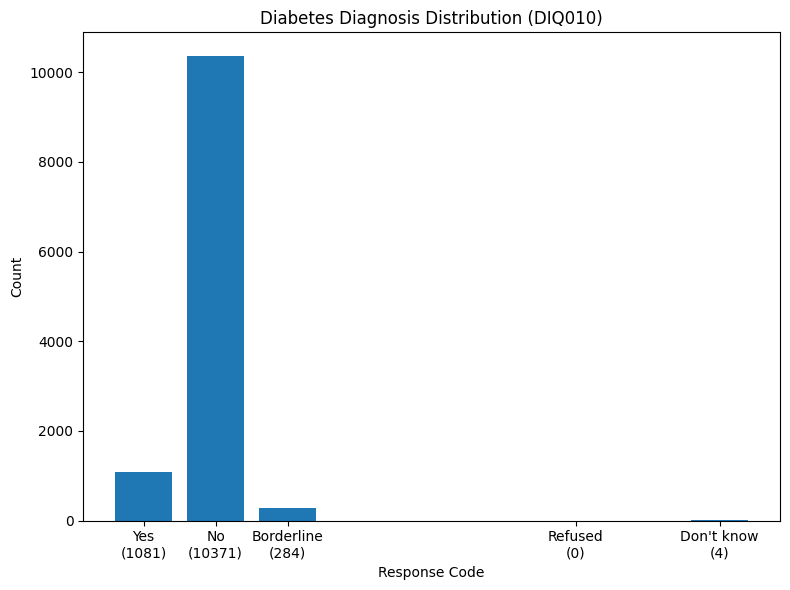

In [8]:
# Visualizing Diabetes Diagnosis Distribution
counts = df['Doctor told you have diabetes'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 3: "Borderline", 7: "Refused", 9: "Don't know"}

# Create a bar plot using matplotlib
plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Diabetes Diagnosis Distribution (DIQ010)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/iabetes_diagnosis_distribution.png")
plt.show()

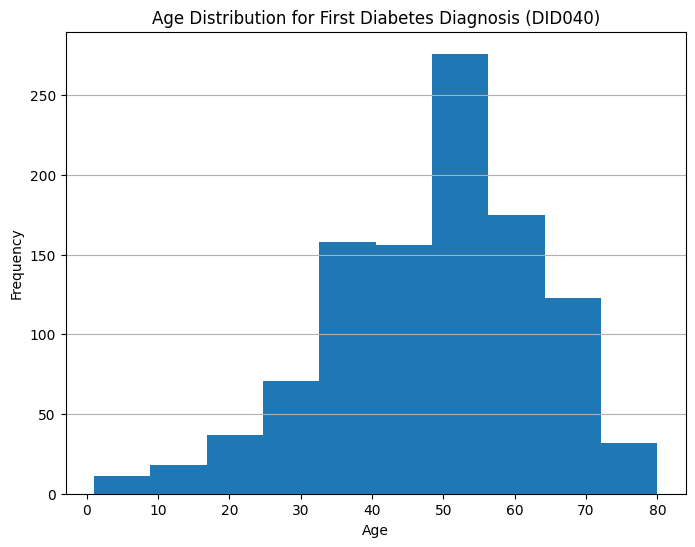

In [9]:
# Graph for Age when first told you had diabetes
age_data = df['Age when first told you had diabetes'].dropna()
age_data_clean = age_data[(age_data >= 1) & (age_data <= 81)] # Ignore codes 666, 777, 999, .

plt.figure(figsize=(8, 6))
plt.hist(age_data_clean)
plt.title('Age Distribution for First Diabetes Diagnosis (DID040)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.savefig("img/age_distribution_diabetes_diagnosis.png")
plt.show()

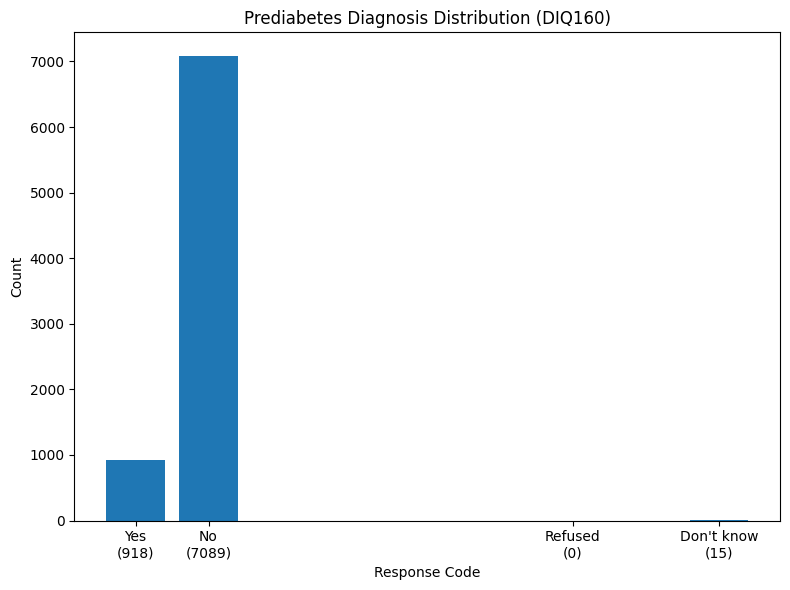

In [10]:
# Graph for Ever told you have prediabetes
counts = df['Ever told you have prediabetes'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Prediabetes Diagnosis Distribution (DIQ160)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/prediabetes_diagnosis_distribution.png")
plt.show()

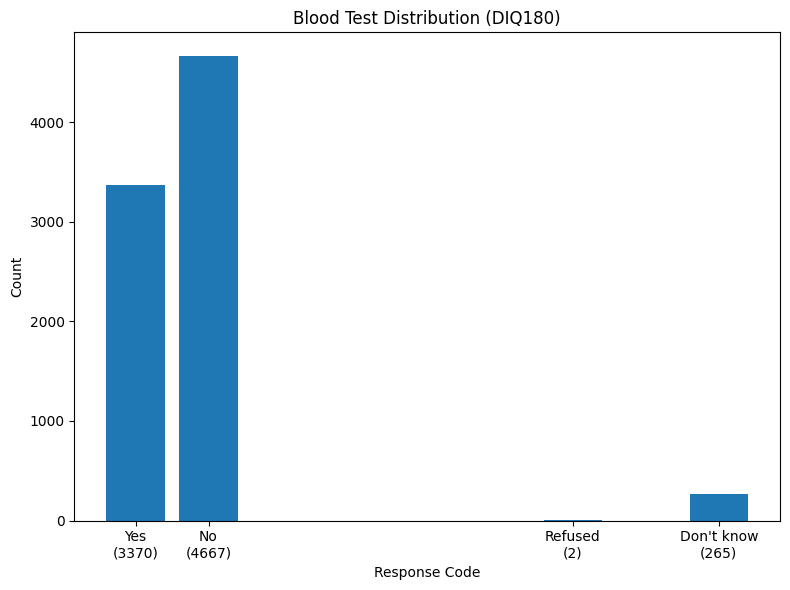

In [11]:
# Graph for Had blood tested past three years
counts = df['Had blood tested past three years'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Blood Test Distribution (DIQ180)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/blood_test_distribution.png")
plt.show()

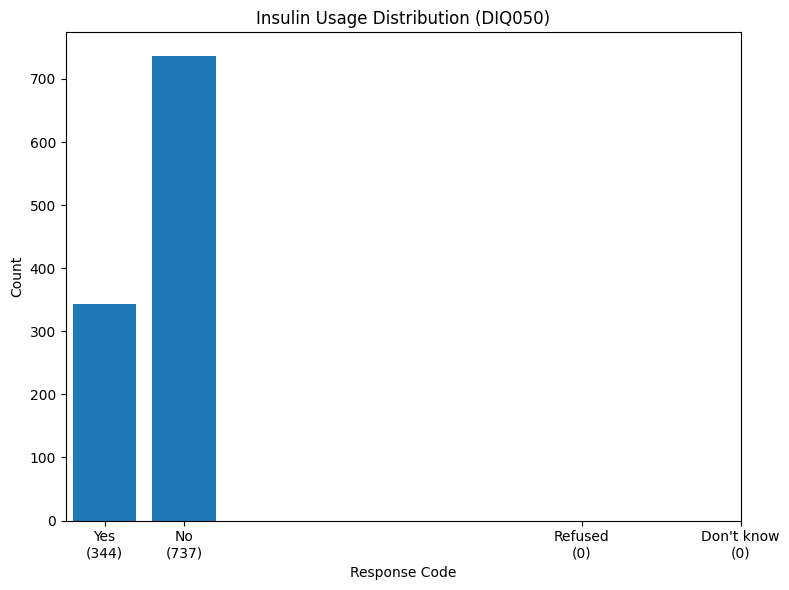

In [12]:
# Graph for Taking insulin now
counts = df['Taking insulin now'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Insulin Usage Distribution (DIQ050)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/insulin_usage_distribution.png")
plt.show()

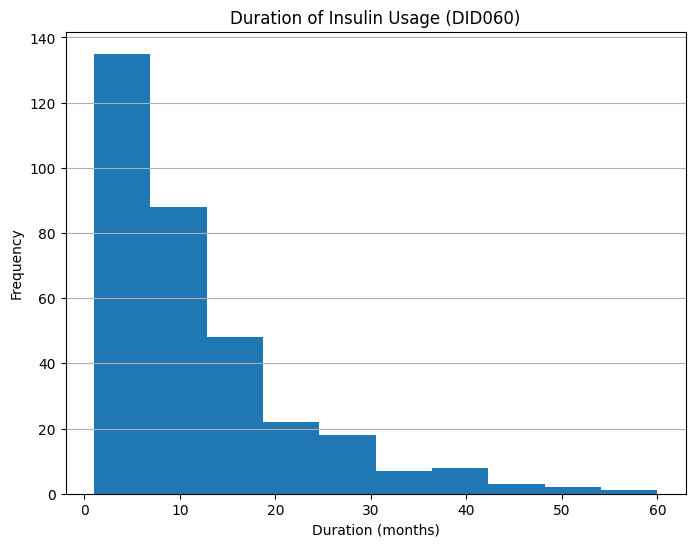

In [13]:
# Graph for How long taking insulin
insulin_duration = df['How long taking insulin'].dropna()
insulin_duration_clean = insulin_duration[(insulin_duration >= 1) & (insulin_duration <= 61)] # Ignore codes 666, 777, 999, .

plt.figure(figsize=(8, 6))
plt.hist(insulin_duration_clean)
plt.title('Duration of Insulin Usage (DID060)')
plt.xlabel('Duration (months)')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.savefig("img/insulin_duration_distribution.png")
plt.show()

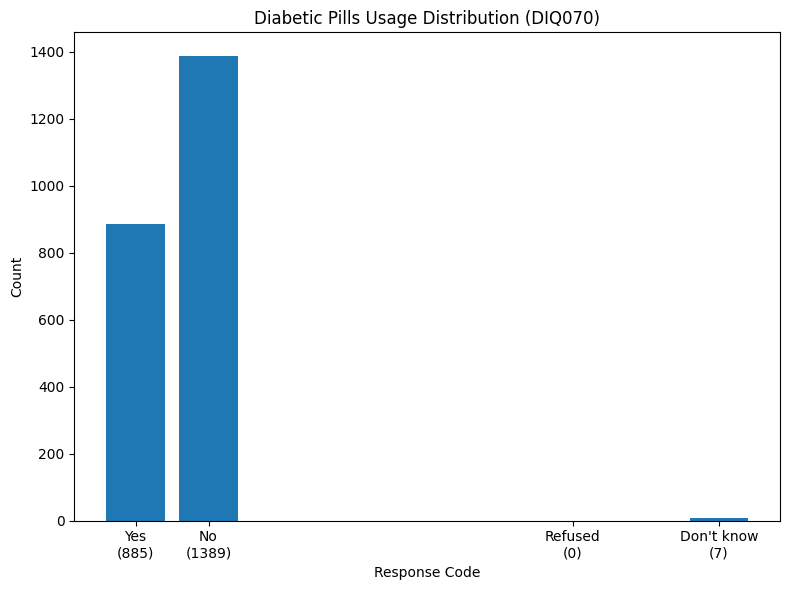

In [14]:
# Graph for Take diabetic pills to lower blood sugar
counts = df['Take diabetic pills to lower blood sugar'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Diabetic Pills Usage Distribution (DIQ070)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/diabetic_pills_distribution.png")
plt.show()

In [15]:
# Save Cleaned Subset
df.to_csv("cleaned/diabetes_cleaned_subset.csv", index=False)

---
## Making Connections & Insights

In [16]:
# code for combining all of the datasets into one

# import diabetes dataset
file_path = "diabetes_data/Diabetes_DIQ_L.xpt"
df, meta = pyreadstat.read_xport(file_path, encoding='cp1252')

# goes through all other files and merges them into the dataframe
dir = 'all_data'
ind = 0
for file in os.scandir(dir):
    if file.is_file():
        print(file)
        ind += 1
        newdf, meta = pyreadstat.read_xport(file, encoding='cp1252')
        df = df.merge(newdf, on="SEQN", how="left", copy=False, suffixes=[f'_x{ind}', f'_y{ind}'])

# create csv from combined dataframe
print(df.head())
df.to_csv('all_data.csv', index=False)

<DirEntry 'UCPREG_L.xpt'>
<DirEntry 'RXQ_RX_L.xpt'>
<DirEntry 'HSCRP_L.xpt'>
<DirEntry 'HEQ_L.xpt'>
<DirEntry 'OHQ_L.xpt'>
<DirEntry 'RXQASA_L.xpt'>
<DirEntry 'HIQ_L.xpt'>
<DirEntry 'LUX_L.xpt'>
<DirEntry 'KIQ_U_L.xpt'>
<DirEntry 'HSQ_L.xpt'>
<DirEntry 'FOLFMS_L.xpt'>
<DirEntry 'DBQ_L.xpt'>
<DirEntry 'RHQ_L.xpt'>
<DirEntry 'CBC_L.xpt'>
<DirEntry 'IMQ_L.xpt'>
<DirEntry 'HOQ_L.xpt'>
<DirEntry 'FNQ_L.xpt'>
<DirEntry 'ACQ_L.xpt'>
<DirEntry 'TST_L.xpt'>
<DirEntry 'DPQ_L.xpt'>
<DirEntry 'SLQ_L.xpt'>
<DirEntry 'GLU_L.xpt'>
<DirEntry 'SMQRTU_L.xpt'>
<DirEntry 'AUQ_L.xpt'>
<DirEntry 'AGP_L.xpt'>
<DirEntry 'BPXO_L.xpt'>
<DirEntry 'HUQ_L.xpt'>
<DirEntry 'SMQFAM_L.xpt'>
<DirEntry 'VID_L.xpt'>
<DirEntry 'FOLATE_L.xpt'>
<DirEntry 'PUQMEC_L.xpt'>
<DirEntry 'PBCD_L.xpt'>
<DirEntry 'DEMO_L.xpt'>
<DirEntry 'ECQ_L.xpt'>
<DirEntry 'BMX_L.xpt'>
<DirEntry 'HDL_L.xpt'>
<DirEntry 'BAX_L.xpt'>
<DirEntry 'TCHOL_L.xpt'>
<DirEntry 'PAQ_L.xpt'>
<DirEntry 'PAQY_L.xpt'>
<DirEntry 'FERTIN_L.xpt'>
<DirEntry 'MCQ_L.xpt

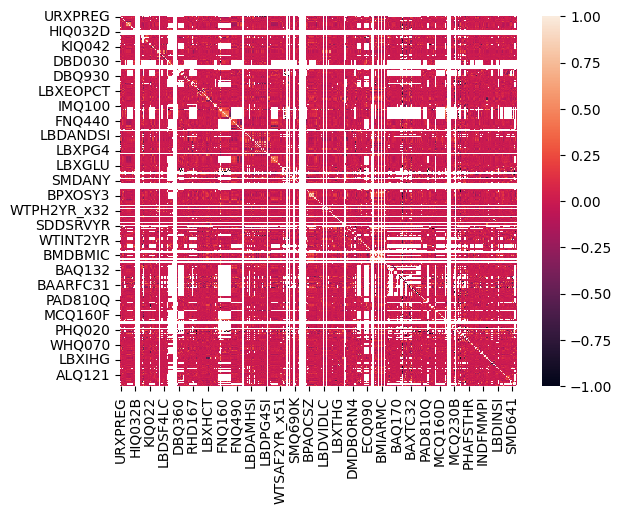

In [ ]:
# import csv
df = pd.read_csv('all_data.csv')

df_ml = df.copy()

# Filter out missing values in the target
df_ml = df_ml[df_ml['DIQ010'].isin([1, 2])]  # Keep only Yes/No answers
df_ml['diabetes'] = np.where(df_ml['DIQ010'] == 1, 1, 0)

# clean out all features from the diabetes dataset
df_clean = df_ml.drop(columns=['DIQ010', 'DIQ160', 'DIQ180', 'DIQ050', 'DID060', 'DIQ060U', 'DIQ070', 'SEQN', 'DID040'])

# making correlation graph - only include numeric columns
corrmat = df_clean.corr(numeric_only=True)
round(corrmat, 2)
sns.heatmap(corrmat)
plt.show()

In [18]:
print(corrmat.head())

# gets lists of correlations to DIQ010 (diagnosed w/ diabetes) and the corresponding codes
correlations = corrmat['diabetes'].dropna().tolist()[2:]
codes = corrmat['diabetes'].dropna().keys().tolist()[2:]

print(correlations)
print(codes)

              URXPREG    RXQ033    RXQ050  WTPH2YR_x11  LBXHSCRP  LBDHRPLC  \
URXPREG      1.000000 -0.021303  0.045402    -0.009975  0.007688  0.064873   
RXQ033      -0.021303  1.000000       NaN     0.047615 -0.103582  0.113482   
RXQ050       0.045402       NaN  1.000000    -0.092393  0.085392 -0.077449   
WTPH2YR_x11 -0.009975  0.047615 -0.092393     1.000000 -0.019842  0.021068   
LBXHSCRP     0.007688 -0.103582  0.085392    -0.019842  1.000000 -0.074722   

               HEQ010    OHQ845    OHQ620    OHQ630  ...    ALQ170    SMQ020  \
URXPREG     -0.002592 -0.005507 -0.042866 -0.023128  ... -0.139726 -0.020476   
RXQ033      -0.013098 -0.162856  0.087710  0.045161  ...  0.030487  0.083683   
RXQ050       0.012742  0.242791 -0.109419 -0.137928  ...  0.040484 -0.131785   
WTPH2YR_x11 -0.011722  0.009730 -0.004673  0.083853  ...  0.031079  0.071986   
LBXHSCRP     0.001162  0.090539 -0.060540 -0.056945  ...  0.010652 -0.038778   

               SMQ040    SMD641    SMD650  SMD100M

In [ ]:
# create a list of codes with decent correlation, format: (code, correlation)
filtCorrs = []
for i in range(len(correlations)):
    if correlations[i] > 0.15 or correlations[i] < -0.15:
        filtCorrs.append((codes[i], correlations[i]))

print(filtCorrs)
print(f'There are {len(filtCorrs)} codes with a correlation stronger than 0.15')

[('RXQ050', 0.3862591718577147), ('OHQ845', 0.21337814060464844), ('RXQ510', -0.19495141935742788), ('LUARXIN', 0.3962646512170841), ('LUXSMED', 0.16373469251703449), ('LUXCAPM', 0.22847588216930007), ('KIQ005', 0.1589936373741843), ('KIQ481', 0.1544771837779573), ('LBXSF6SI', 0.17782047368898268), ('RHQ031', 0.2122161388867004), ('RHD280', -0.15390995493734794), ('LBXRDW', 0.1564153078539761), ('FNQ440', 0.2735089397139917), ('FNQ490', 0.1910015817054546), ('FNDADI', -0.18255462848194112), ('FNDAEDI', -0.17324887453424306), ('LBXDHE', -0.15929603198730707), ('LBDDHESI', -0.15930036907649459), ('LBXGLU', 0.5711083979177024), ('LBDGLUSI', 0.5710826310725455), ('SMQ740', -0.22239388869990667), ('SMQ690D', -0.249236847464597), ('BPAOCSZ', 0.16018970906004598), ('BPXOSY1', 0.1640622287626787), ('BPXOSY2', 0.1730957415073154), ('BPXOSY3', 0.16571479524087504), ('HUQ010', 0.30817492474287117), ('RIDAGEYR', 0.3148759159375084), ('DMDHHSIZ', -0.15804213602520978), ('BMXWT', 0.2285209908033361)

Text(0, 0.5, 'Amount of Features')

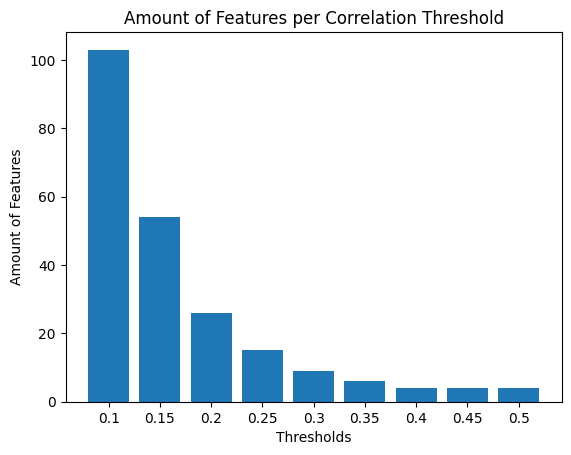

In [20]:
# graph of the amount of features we can get with different correlation thresholds

amounts = []
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

for t in thresholds:
    filtCorrsGraph = []
    for i in range(len(correlations)):
        if correlations[i] > t or correlations[i] < t*-1:
            filtCorrsGraph.append((codes[i], correlations[i]))
    amounts.append(len(filtCorrsGraph))


plt.bar(list(map(str, thresholds)), amounts, label = thresholds)
plt.title('Amount of Features per Correlation Threshold')
plt.xlabel('Thresholds')
plt.ylabel('Amount of Features')

In [ ]:
# dictionary for storing the database and feature name for each code
codeDict = {
    "DIQ070": ("Diabetes", "Take diabetic pills to lower blood sugar"),
    "BAXMSTAT": ("Balance", "MRT exam status"),
    "BAX5STAT": ("Balance", "Eligibility for Condition 5"),
    "BAARFC11": ("Balance", "MRT cond. 1, trial 1, reason stopped"),
    "BAXPF12": ("Balance", "MRT cond. 1, trial 2, eyes open"),
    "BAXTC12": ("Balance", "MRT cond. 1, trial 2, time"),
    "BAARFC12": ("Balance", "MRT cond. 1, trial 2, reason stopped"),
    "BAXPF22": ("Balance", "MRT cond. 2, trial 2, eyes closed"),
    "BAXTC22": ("Balance", "MRT cond. 2, trial 2, time"),
    "BAARFC31": ("Balance", "MRT cond. 3, trial 1, reason stopped"),
    "BAXTC32": ("Balance", "MRT cond. 3, trial 2, time"),
    "BAARFC32": ("Balance", "MRT cond. 3, trial 2, reason stopped"),
    "BAXTC41": ("Balance", "MRT cond. 4, trial 1, time"),
    "BAXTC42": ("Balance", "MRT cond. 4, trial 2, time"),
    "BMXWT": ("Body Measures", "Weight (kg)"),
    "BMIHT": ("Body Measures", "Standing Height Comment"),
    "BMXBMI": ("Body Measures", "Body Mass Index (kg/m**2)"),
    "BMXARMC": ("Body Measures", "Arm Circumference (cm)"),
    "BMXWAIST": ("Body Measures", "Waist Circumference (cm)"),
    "BPQ020": ("Blood Pressure & Cholesterol", "Ever told you had high blood pressure"),
    "BPQ080": ("Blood Pressure & Cholesterol", "Doctor told you - high cholesterol level"),
    "BPQ101D": ("Blood Pressure & Cholesterol", "Taking meds to lower blood cholesterol?"),
    "BPAOCSZ": ("Blood Pressure - Oscillometric Measurements", "Coded cuff size - oscillometric"),
    "BPXOSY1": ("Blood Pressure - Oscillometric Measurements", "Systolic - 1st oscillometric reading"),
    "BPXOSY2": ("Blood Pressure - Oscillometric Measurements", "Systolic - 2nd oscillometric reading"),
    "BPXOSY3": ("Blood Pressure - Oscillometric Measurements", "Systolic - 3rd oscillometric reading"),
    "LBXRDW": ("Complete Blood Count with 5-Part Differential in Whole Blood (CBC_L)", "Red cell distribution width (%)"),
    "RIDAGEYR": ("Demographic Variables and Sample Weights", "Age in years at screening"),
    "DMDEDUC2": ("Demographic Variables and Sample Weights", "Education level - Adults 20+"),
    "DMDHHSIZ": ("Demographic Variables and Sample Weights", "Total number of people in the Household"),
    "PHACOFHR": ("Fasting Questionnaire", "Coffee/tea fast time (hours)"),
    "PHACOFMN": ("Fasting Questionnaire", "Coffee/tea fast time (minutes)"),
    "PHAALCMN": ("Fasting Questionnaire", "Alcohol fast time (minutes)"),
    "LBXFER": ("Ferritin", "Ferritin(ng/mL)"),
    "LBDFERSI": ("Ferritin", "Ferritin(mewg/L)"),
    "FNQ041": ("Functioning", "Difficulty hearing even w/ hearing aids"),
    "FNQ440": ("Functioning", "Difficulty walking or climbing steps"),
    "FNQ490": ("Functioning", "Difficulty using hands and fingers"),
    "FNDADI": ("Functioning", "WG-SS Disability Indicator 18+"),
    "FNDAEDI": ("Functioning", "WG-SS Enhanced Disability Indicator 18+"),
    "LBXSF6SI": ("Serum Folate Forms - Total & Individual - Serum", "Mefox oxidation product (nmol/L)"),
    "LBXGH": ("Glycohemoglobin", "Glycohemoglobin (%)"),
    "LBXGLU": ("Plasma Fasting Glucose", "Fasting Glucose (mg/dL)"),
    "LBDGLUSI": ("Plasma Fasting Glucose", "Fasting Glucose (mmol/L)"),
    "HUQ010": ("Hospital Utilization & Access to Care", "General health condition"),
    "LBXIN": ("Insulin", "Insulin (uU/mL)"),
    "LBDINSI": ("Insulin", "Insulin (pmol/L)"),
    "KIQ005": ("Kidney Conditions - Urology", "How often have urinary leakage"),
    "KIQ052": ("Kidney Conditions - Urology", "How much were daily activities affected"),
    "KIQ481": ("Kidney Conditions - Urology", "How many times wake up and urinate?"),
    "LUARXIN": ("Liver Ultrasound Transient Elastography", "Reason ineligible"),
    "LUXSMED": ("Liver Ultrasound Transient Elastography", "Median stiffness (E), kilopascals (kPa)"),
    "LUXCAPM": ("Liver Ultrasound Transient Elastography", "Median CAP, decibels per meter (dB/m)"),
    "OCD150": ("Occupation", "Type of work done last week"),
    "OHQ845": ("Occupation", "Rate the health of your teeth and gums"),
    "RHQ031": ("Reproductive Health", "Had regular periods in past 12 months"),
    "RHQ078": ("Reproductive Health", "Ever treated for a pelvic infection/PID"),
    "RHD280": ("Reproductive Health", "Had a hysterectomy?"),
    "RXQ510": ("Preventive Aspirin Use", "Dr told to take daily low-dose aspirin?"),
    "RXQ033": ("Prescription Medications", "Taken prescription medicine, past month"),
    "RXQ050": ("Prescription Medications", "Number of prescription medicines taken"),
    "SMQ740": ("Smoking - Recent Tobacco Use", "# days smoked pipe over last 5 days"),
    "SMQ690D": ("Smoking - Recent Tobacco Use", "Used last 5 days - Chewing tobacco"), 
    "LBDAMHLC": ("Sex Steroid Hormone Panel - Serum", "Anti-Mullerian hormone Comment Code"),
    "LBXDHE": ("Sex Steroid Hormone Panel - Serum", "DHEAS (mewg/dL)"),
    "LBDDHESI": ("Sex Steroid Hormone Panel - Serum", "DHEAS (mewmol/L)"),
    "BMXARML": ("Body Measures", "Upper Arm Length (cm)"),
    "BMXHIP": ("Body Measures", "Hip Circumference (cm)"),
    "RXQ520": ("Preventive Aspirin Use", "Taking low-dose aspirin on your own?"),
    "LBXVD3MS": ("Vitamin D", "25OHD3 (nmol/L)"),
    "RHQ305": ("Reproductive Health", "Had both ovaries removed?"),
    "LBDVD3LC": ("Vitamin D", "25OHD3 comment code"),
    "LBDVD2LC": ("Vitamin D", "25OHD2 comment code"),
    "SMD100MN": ("Smoking - Cigarette Use", "Cigarette Menthol indicator"),
    "WTINT2YR": ("Demographic Variables and Sample Weights", "Full sample 2-year interview weights"),
    "RXQ515": ("Preventive Aspirin Use", "Followed advice, took low-does aspirin"),
    "SMD650": ("Smoking - Recent Tobacco Use", "Avg # cigarettes/day during past 30 days"),
    "LBDHDD": ("Cholesterol - High-Density Lipoprotein", "Direct HDL-Cholesterol (mg/dL)"),
    "LBDHDDSI": ("Cholesterol - High-Density Lipoprotein", "Direct HDL-Cholesterol (mmol/L)"),
    "PAD790Q": ("Physical Activity", "Frequency of moderate LTPA"),
    "PAD810U": ("Physical Activity", "Vigorous LTPA unit (day/week/month/year)"),
    "WTMEC2YR": ("Demographic Variables and Sample Weights", "Full sample 2-year MEC exam weight"),
    "LBXRBCSI": ("Complete Blood Count with 5-Part Differential in Whole Blood (CBC_L)", "Red blood call count (million cells/uL)"),
    "LBXHCT": ("Complete Blood Count with 5-Part Differential in Whole Blood (CBC_L)", "Hematocrit (%)"),
    "LBXMCHSI": ("Complete Blood Count with 5-Part Differential in Whole Blood (CBC_L)", "Mean cell hemoglobin (pg)"),
    "LBXFSH": ("Sex Steroid Horomone Panel", "Follicle Stimulating Hormone (mIU/mL)"),
    "RIDRETH3": ("Demographic Variables and Sample Weights", "Race/Hispanic origin w/ NH Asian"),
    "RIDSTATR": ("Interview/Examination status"),
    "LBXLUH": ("Sex Steroid Horomone Panel", "Luteinizing Horomone (mIU/mL)"),
    "SMAQUEX2": ("Smoking - Cigarette Use", "Questionnaire Mode Flag"),
    "LBDEONO": ("Complete Blood Count with 5-Part Differential in Whole Blood (CBC_L)", "Eosinophils number (1000 cells/uL)"),
}

['Prescription Medications', 'Occupation', 'Preventive Aspirin Use', 'Liver Ultrasound Transient Elastography', 'Liver Ultrasound Transient Elastography', 'Liver Ultrasound Transient Elastography', 'Kidney Conditions - Urology', 'Kidney Conditions - Urology', 'Serum Folate Forms - Total & Individual - Serum', 'Reproductive Health', 'Reproductive Health', 'Complete Blood Count with 5-Part Differential in Whole Blood (CBC_L)', 'Functioning', 'Functioning', 'Functioning', 'Functioning', 'Sex Steroid Hormone Panel - Serum', 'Sex Steroid Hormone Panel - Serum', 'Plasma Fasting Glucose', 'Plasma Fasting Glucose', 'Smoking - Recent Tobacco Use', 'Smoking - Recent Tobacco Use', 'Blood Pressure - Oscillometric Measurements', 'Blood Pressure - Oscillometric Measurements', 'Blood Pressure - Oscillometric Measurements', 'Blood Pressure - Oscillometric Measurements', 'Hospital Utilization & Access to Care', 'Demographic Variables and Sample Weights', 'Demographic Variables and Sample Weights', 'Bod

/var/folders/4c/xrxv09b531941dc_6xkrdcb40000gn/T/ipykernel_69830/3629750122.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20c')


Text(0.5, 1.0, 'Amount of High Correlated Features per Dataset')

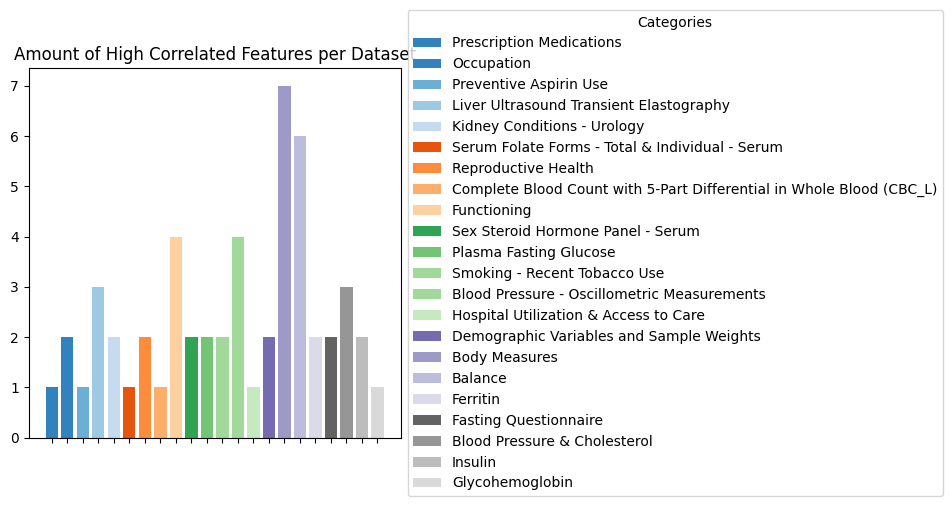

In [ ]:
# create bar chart showing the number of highly correlated features per dataset

# get list of all databases
all_databases = []
for i in range(len(filtCorrs) - 1):
    all_databases.append(codeDict[filtCorrs[i][0]][0])

print(all_databases)

# only gets unique database names
unique_db = []
for i in all_databases:
    if i not in unique_db:
        unique_db.append(i)

# get counts per database
counts = []
for i in unique_db:
    counts.append(all_databases.count(i))

print(counts)

# make bar chart
cmap = get_cmap('tab20c')
colors = [cmap(i / len(unique_db)) for i in range(len(unique_db))]

fig, ax = plt.subplots()
bars = ax.bar(range(len(counts)), counts, color=colors)

ax.set_xticks(range(len(unique_db)))
ax.set_xticklabels([''] * len(unique_db))

legend_elements = [Patch(facecolor=colors[i], label=unique_db[i]) for i in range(len(unique_db))]

# shrink plot to make space for legend
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.75, box.height])

# add legend outside to the right with multiple columns if needed
ax.legend(handles=legend_elements,
          title="Categories",
          loc='center left',
          bbox_to_anchor=(1, 0.5),
          ncol=1)  # You can set ncol=2 if many labels

plt.title('Amount of High Correlated Features per Dataset')

In [ ]:
# sort the correlated features and get the top 10
sorted_corrs = sorted(filtCorrs, key=lambda x: x[1], reverse=True)
top_10 = []
for i in range(1,11):
    feature = sorted_corrs[i][0]
    importance = sorted_corrs[i][1]
    top_10.append((codeDict[feature][1], importance))
print(top_10)

[('Glycohemoglobin (%)', 0.638715794729773), ('Fasting Glucose (mg/dL)', 0.5711083979177024), ('Fasting Glucose (mmol/L)', 0.5710826310725455), ('Reason ineligible', 0.3962646512170841), ('Number of prescription medicines taken', 0.3862591718577147), ('Age in years at screening', 0.3148759159375084), ('General health condition', 0.30817492474287117), ('Waist Circumference (cm)', 0.2861023372289315), ('Coffee/tea fast time (hours)', 0.2800416927886729), ('Difficulty walking or climbing steps', 0.2735089397139917)]


---
## Regressions

In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Use the dataset with your identified correlated features
df = pd.read_csv('all_data.csv')

# Define target variable (1 for diabetes, 2 for no diabetes)
# We'll convert it to a binary format (0 for no diabetes, 1 for diabetes)
df_ml = df.copy()

# Filter out missing values in the target
df_ml = df_ml[df_ml['DIQ010'].isin([1, 2])]  # Keep only Yes/No answers
df_ml['diabetes'] = np.where(df_ml['DIQ010'] == 1, 1, 0)  # 1=Yes, 2=No in original data

# Select features with correlation > 0.2 (or use your filtCorrs list)
# Let's pick a subset of meaningful features based on your correlation analysis
# run following for set list of features
#selected_features = [
#    'BMXBMI',            # Body Mass Index
#    'BMXWAIST',          # Waist Circumference
#    'BPQ020',            # High blood pressure history
#    'RIDAGEYR',          # Age in years
#    'LBXGH',             # Glycohemoglobin
#    'LBXGLU',            # Fasting Glucose
#    'LBXIN'              # Insulin
#]

# run following for list of features gotten from linear correlation calculations
selected_features = []
for i in range(len(filtCorrs) - 1):
    selected_features.append(filtCorrs[i][0])

# Display the selected dataset
print("Selected features shape:", df_ml[selected_features + ['diabetes']].shape)
df_ml[selected_features + ['diabetes']].head()

Selected features shape: (11452, 54)


,RXQ050,OHQ845,RXQ510,LUARXIN,LUXSMED,LUXCAPM,KIQ005,KIQ481,LBXSF6SI,RHQ031,...,PHACOFHR,PHACOFMN,BPQ020,BPQ080,BPQ101D,OCD150,LBXIN,LBDINSI,LBXGH,diabetes
0,1.0,1.0,2.0,NaN,9.5,380.0,NaN,NaN,0.829,NaN,...,NaN,NaN,1.0,2.0,2.0,1.0,15.53,93.18,5.6,0
1,1.0,2.0,2.0,NaN,3.9,345.0,2.0,2.0,2.940,NaN,...,NaN,NaN,1.0,2.0,2.0,1.0,19.91,119.46,5.6,0
2,1.0,4.0,1.0,NaN,7.6,255.0,1.0,2.0,2.450,1.0,...,NaN,NaN,2.0,1.0,1.0,1.0,16.33,97.98,6.2,1
3,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.150,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


Initial data shape: (11452, 54)

Missing values by column:
RXQ050       5468
OHQ845          1
RXQ510       5982
LUARXIN     11259
LUXSMED      4971
LUXCAPM      4972
KIQ005       6418
KIQ481       6439
LBXSF6SI     4317
RHQ031       8194
RHD280       8691
LBXRDW       4084
FNQ440       3584
FNQ490       3585
FNDADI       3583
FNDAEDI      3583
LBXDHE       4594
LBDDHESI     4594
LBXGLU       7910
LBDGLUSI     7910
SMQ740      11427
SMQ690D     11411
BPAOCSZ      4068
BPXOSY1      4158
BPXOSY2      4170
BPXOSY3      4195
HUQ010          0
RIDAGEYR        0
DMDHHSIZ        0
BMXWT        3060
BMIHT       11322
BMXBMI       3212
BMXARML      3218
BMXARMC      3223
BMXWAIST     3484
BMXHIP       4890
BAARFC11    11405
BAXPF22     11359
BAXTC32     11376
BAARFC32    11433
BAXTC41      7711
BAXTC42     10193
LBXFER       9533
LBDFERSI     9533
PHACOFHR    11423
PHACOFMN    11423
BPQ020       3229
BPQ080       3229
BPQ101D      3229
OCD150       3242
LBXIN        8061
LBDINSI      8061
LBXGH

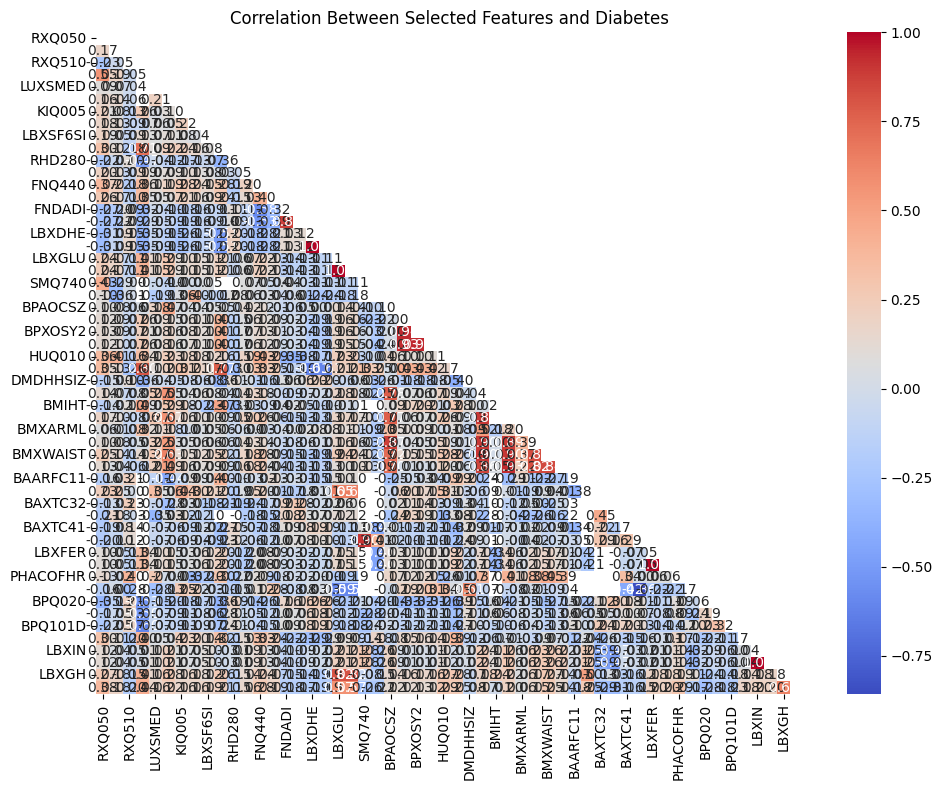

In [26]:
# Handling missing values and preprocessing
df_clean = df_ml[selected_features + ['diabetes']].copy()
print(f"Initial data shape: {df_clean.shape}")

# Check missing values
missing_values = df_clean.isnull().sum()
print("\nMissing values by column:")
print(missing_values)

# Drop rows where too many features are missing (you may adjust this)
df_clean = df_clean.dropna(thresh=len(selected_features) // 2 + 2)  # Keep rows with at least half of features + target
print(f"After removing rows with too many missing values: {df_clean.shape}")

# Plot correlations of selected features
plt.figure(figsize=(10, 8))
corr = df_clean[selected_features + ['diabetes']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", mask=mask)
plt.title('Correlation Between Selected Features and Diabetes')
plt.tight_layout()
plt.show()

In [27]:
# Split the data
X = df_clean[selected_features]
y = df_clean['diabetes']

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define preprocessing for numeric columns (scaling)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

# Create preprocessing and modeling pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Train the model
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['RXQ050', 'OHQ845', 'RXQ510', 'LUARXIN', 'LUXSMED', 'LUXCAPM', 'KIQ005',
       'KIQ481', 'LBXSF6SI', 'RHQ031', 'RHD280', 'LBXRDW', 'FNQ440', 'FNQ490',
       'FNDADI', 'FNDAEDI', 'LBXDHE', 'LBDDHESI', 'LBXGLU', 'L...
       'SMQ740', 'SMQ690D', 'BPAOCSZ', 'BPXOSY1', 'BPXOSY2', 'BPXOSY3',
       'HUQ010', 'RIDAGEYR', 'DMDHHSIZ', 'BMXWT', 'BMIHT', 'BMXBMI', 'BMXARML',
       'BMXARMC', 'BMXWAIST', 'BMXHIP', 'BAARFC11', 'BAXPF22', 'BAXTC32',
       'BAARFC32', 'BAXTC41', 'BAXTC42', 'LBXFER', 'LBDFERSI', 'PHACOFHR',
       'PHACOFMN', 'BPQ020', 'BPQ080', 'BPQ101D', 'OCD150', 'LBXIN', 'LBDINSI',
       'LBXGH'],
      dtype='object'))])),
                ('classifier', LogisticRegression(random_state=42))])

Classification Accuracy: 0.9305

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1072
           1       0.80      0.64      0.71       165

    accuracy                           0.93      1237
   macro avg       0.87      0.81      0.83      1237
weighted avg       0.93      0.93      0.93      1237



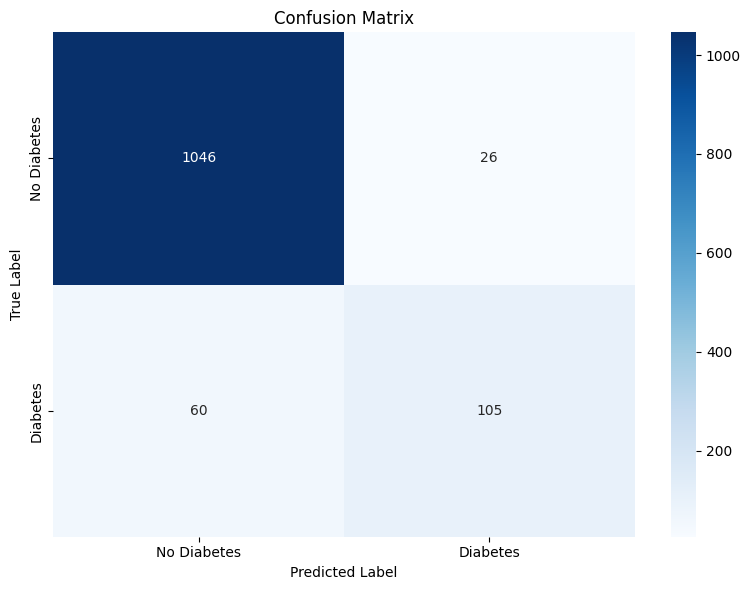

In [28]:
# Evaluate classification performance
y_pred = model_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

PermutationExplainer explainer: 4948it [02:25, 32.04it/s]                          
/var/folders/4c/xrxv09b531941dc_6xkrdcb40000gn/T/ipykernel_69830/1762891886.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[..., 1], X_train)


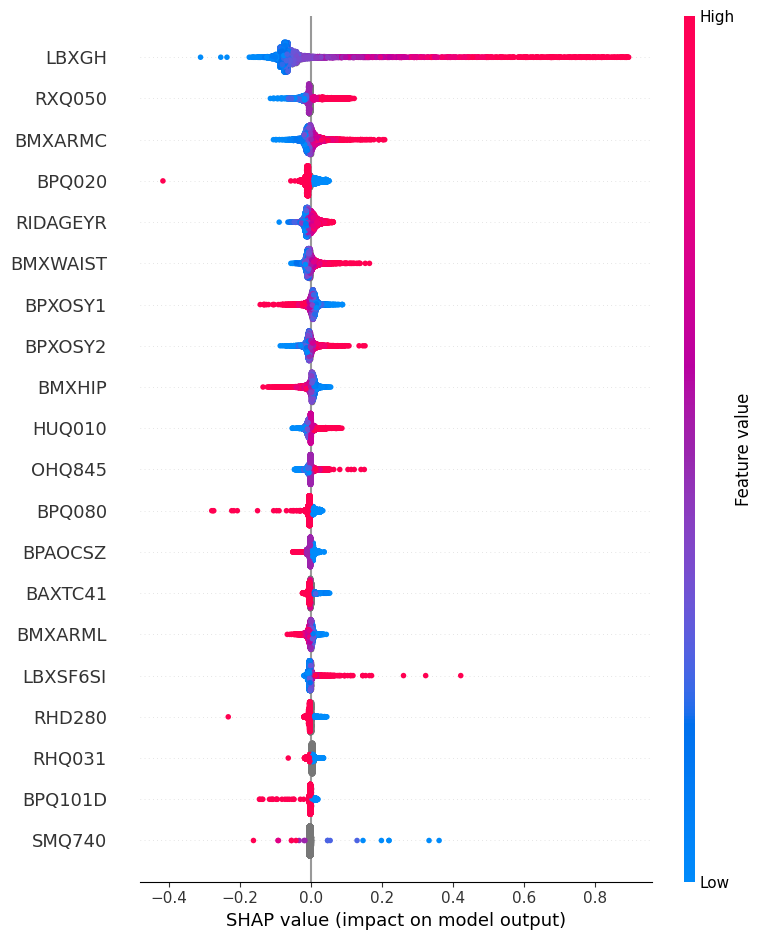

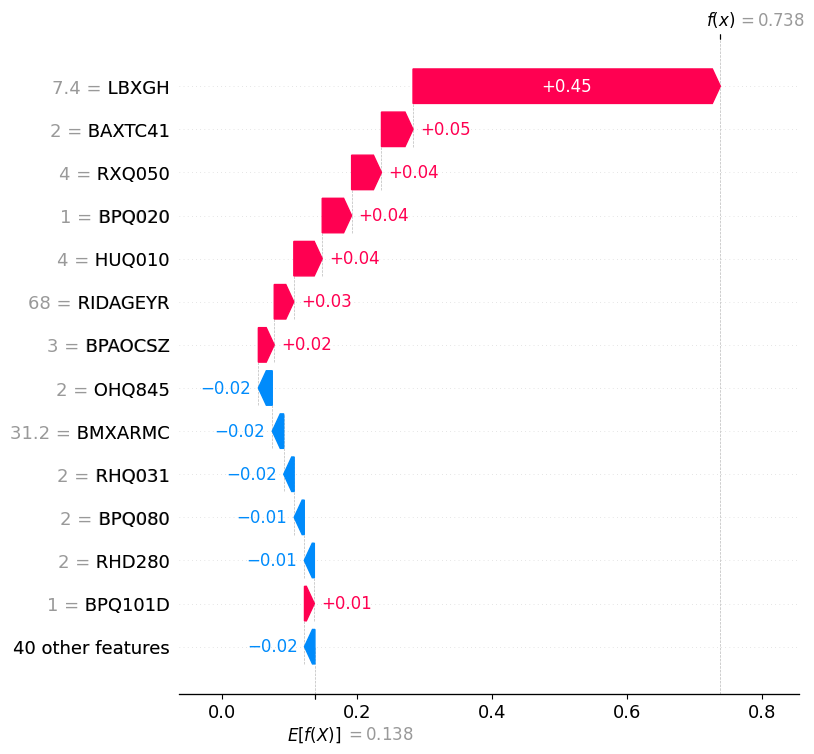

In [ ]:
# create and train pipeline for getting shap values
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]), numeric_features),
])
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
pipeline.fit(X_train, y_train)

masker = shap.maskers.Independent(X_train)

# Wrap the pipeline's predict_proba function (or use a lambda)
explainer = shap.Explainer(pipeline.predict_proba, masker)

# Compute SHAP values for class 1 (positive class)
shap_values = explainer(X_train)

# Plot
shap.summary_plot(shap_values[..., 1], X_train)

# other method for viewing shap values
shap.plots.waterfall(shap_values[5, :, 1], max_display=14)

In [ ]:
# Extract SHAP values for class 1
shap_class1 = shap_values.values[:, :, 1]  # shape now (4955, 55)

# Create DataFrame
shap_df = pd.DataFrame(shap_class1, columns=X_train.columns)

# Compute mean absolute SHAP values
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

# Get top 10 features
top_10 = mean_abs_shap.head(10)
print(top_10)

log_feature_names = top_10.index.tolist()
log_top_10 = []
for i in range(0,10):
    feature = log_feature_names[i]
    log_top_10.append(codeDict[feature][1])
print(log_top_10)


LBXGH       0.111620
RXQ050      0.024603
BMXARMC     0.016229
BPQ020      0.014697
RIDAGEYR    0.012825
BMXWAIST    0.012106
BPXOSY1     0.011635
BPXOSY2     0.010664
BMXHIP      0.010432
HUQ010      0.009987
dtype: float64
['Glycohemoglobin (%)', 'Number of prescription medicines taken', 'Arm Circumference (cm)', 'Ever told you had high blood pressure', 'Age in years at screening', 'Waist Circumference (cm)', 'Systolic - 1st oscillometric reading', 'Systolic - 2nd oscillometric reading', 'Hip Circumference (cm)', 'General health condition']


In [31]:
# Try additional classifier models
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
}

# Compare models
results = {}
for name, classifier in classifiers.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    
    # Perform cross-validation
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    results[name] = cv_scores
    
    print(f"{name} - Cross-validation accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # Fit and predict
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"{name} - Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print()

Logistic Regression - Cross-validation accuracy: 0.9316 ± 0.0033
Logistic Regression - Test accuracy: 0.9337

Random Forest - Cross-validation accuracy: 0.9397 ± 0.0058
Random Forest - Test accuracy: 0.9483



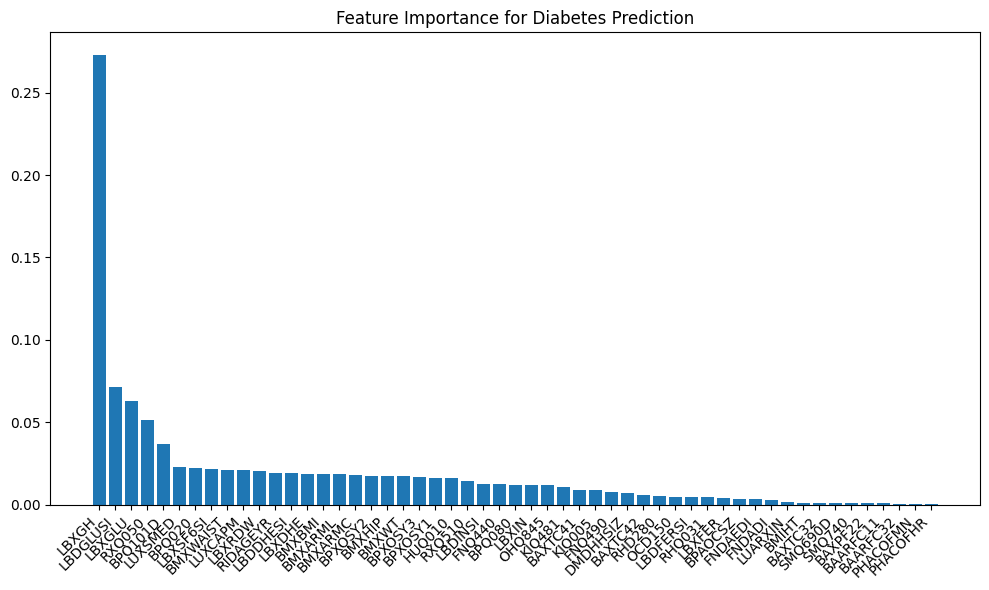

Feature Importance:
LBXGH: 0.2730
LBDGLUSI: 0.0712
LBXGLU: 0.0631
RXQ050: 0.0516
BPQ101D: 0.0365
LUXSMED: 0.0228
BPQ020: 0.0220
LBXSF6SI: 0.0218
BMXWAIST: 0.0211
LUXCAPM: 0.0209
LBXRDW: 0.0203
RIDAGEYR: 0.0190
LBDDHESI: 0.0189
LBXDHE: 0.0185
BMXBMI: 0.0184
BMXARML: 0.0183
BMXARMC: 0.0181
BPXOSY2: 0.0175
BMXHIP: 0.0173
BMXWT: 0.0171
BPXOSY3: 0.0167
BPXOSY1: 0.0162
HUQ010: 0.0160
RXQ510: 0.0142
LBDINSI: 0.0124
FNQ440: 0.0123
BPQ080: 0.0119
LBXIN: 0.0118
OHQ845: 0.0116
KIQ481: 0.0107
BAXTC41: 0.0089
KIQ005: 0.0088
FNQ490: 0.0075
DMDHHSIZ: 0.0073
BAXTC42: 0.0058
RHD280: 0.0052
OCD150: 0.0046
LBDFERSI: 0.0046
RHQ031: 0.0044
LBXFER: 0.0039
BPAOCSZ: 0.0036
FNDAEDI: 0.0035
FNDADI: 0.0030
LUARXIN: 0.0017
BMIHT: 0.0012
BAXTC32: 0.0010
SMQ690D: 0.0008
SMQ740: 0.0008
BAXPF22: 0.0007
BAARFC11: 0.0007
BAARFC32: 0.0003
PHACOFMN: 0.0002
PHACOFHR: 0.0002


In [32]:
# Feature importance analysis with Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])
rf_model.fit(X_train, y_train)

# Extract feature importance
rf_classifier = rf_model.named_steps['classifier']
feature_names = selected_features
feature_importance = rf_classifier.feature_importances_

# Sort features by importance
indices = np.argsort(feature_importance)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title('Feature Importance for Diabetes Prediction')
plt.bar(range(len(feature_importance)), feature_importance[indices], align='center')
plt.xticks(range(len(feature_importance)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print feature importance
print("Feature Importance:")
for i in indices:
    feature = feature_names[i]
    importance = feature_importance[i]
    print(f"{feature}: {importance:.4f}")

In [ ]:
# get top 10 features via feature importance
top_10 = []
for i in range(0,10):
    feature = feature_names[indices[i]]
    importance = feature_importance[indices[i]]
    top_10.append((codeDict[feature][1], importance))
print(top_10)

[('Glycohemoglobin (%)', np.float64(0.2729630866985184)), ('Fasting Glucose (mmol/L)', np.float64(0.07124993916723264)), ('Fasting Glucose (mg/dL)', np.float64(0.06313425229012677)), ('Number of prescription medicines taken', np.float64(0.051556532020651046)), ('Taking meds to lower blood cholesterol?', np.float64(0.036477417040422844)), ('Median stiffness (E), kilopascals (kPa)', np.float64(0.022804429774283323)), ('Ever told you had high blood pressure', np.float64(0.022026719876548518)), ('Mefox oxidation product (nmol/L)', np.float64(0.02181107534764768)), ('Waist Circumference (cm)', np.float64(0.02107402400737918)), ('Median CAP, decibels per meter (dB/m)', np.float64(0.020855520200766045))]


### Regression to predict Glycohemoglobin levels (LBXGH)

Glycohemoglobin (LBXGH) Prediction:
Mean Squared Error: 0.4634
R^2 Score: 0.5522


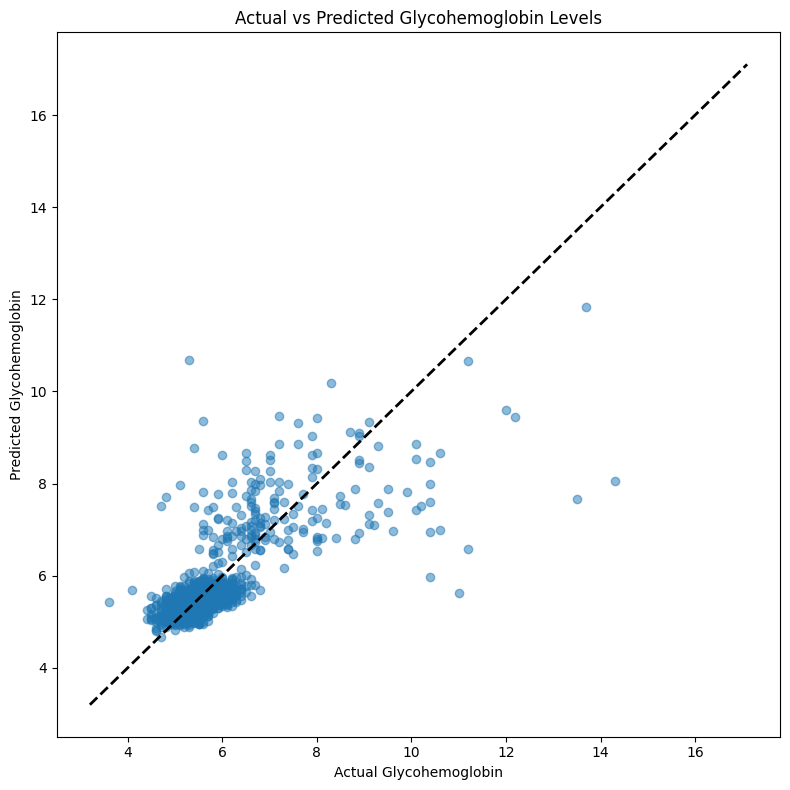

In [34]:
# Define new target
if 'LBXGH' in df_ml.columns:
    # Filter out any missing values in the target
    df_reg = df_ml.dropna(subset=['LBXGH'])
    
    # Choose predictors (removing LBXGH from the features list)
    reg_features = [f for f in selected_features if f != 'LBXGH']
    
    # Add diabetes as a feature
    reg_features.append('diabetes')
    
    # Define X and y for regression
    X_reg = df_reg[reg_features]
    y_reg = df_reg['LBXGH']
    
    # Split data
    X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
    
    # Create a new preprocessor for regression using the columns in reg_features
    numeric_transformer_reg = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    reg_preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer_reg, reg_features)
        ])
    
    # Create regression pipeline
    reg_pipeline = Pipeline(steps=[
        ('preprocessor', reg_preprocessor),
        ('regressor', RandomForestRegressor(random_state=42))
    ])
    
    # Train regression model
    reg_pipeline.fit(X_reg_train, y_reg_train)
    
    # Evaluate regression performance
    y_reg_pred = reg_pipeline.predict(X_reg_test)
    mse = mean_squared_error(y_reg_test, y_reg_pred)
    r2 = r2_score(y_reg_test, y_reg_pred)
    
    print(f"Glycohemoglobin (LBXGH) Prediction:")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R^2 Score: {r2:.4f}")
    
    # Plot actual vs predicted values
    plt.figure(figsize=(8, 8))
    plt.scatter(y_reg_test, y_reg_pred, alpha=0.5)
    plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'k--', lw=2)
    plt.xlabel('Actual Glycohemoglobin')
    plt.ylabel('Predicted Glycohemoglobin')
    plt.title('Actual vs Predicted Glycohemoglobin Levels')
    plt.tight_layout()
    plt.show()


Linear Regression for Glycohemoglobin (LBXGH) Prediction:
Mean Squared Error: 0.5032
R^2 Score: 0.5138

Model Comparison:
Random Forest R^2: 0.5522
Linear Regression R^2: 0.5138


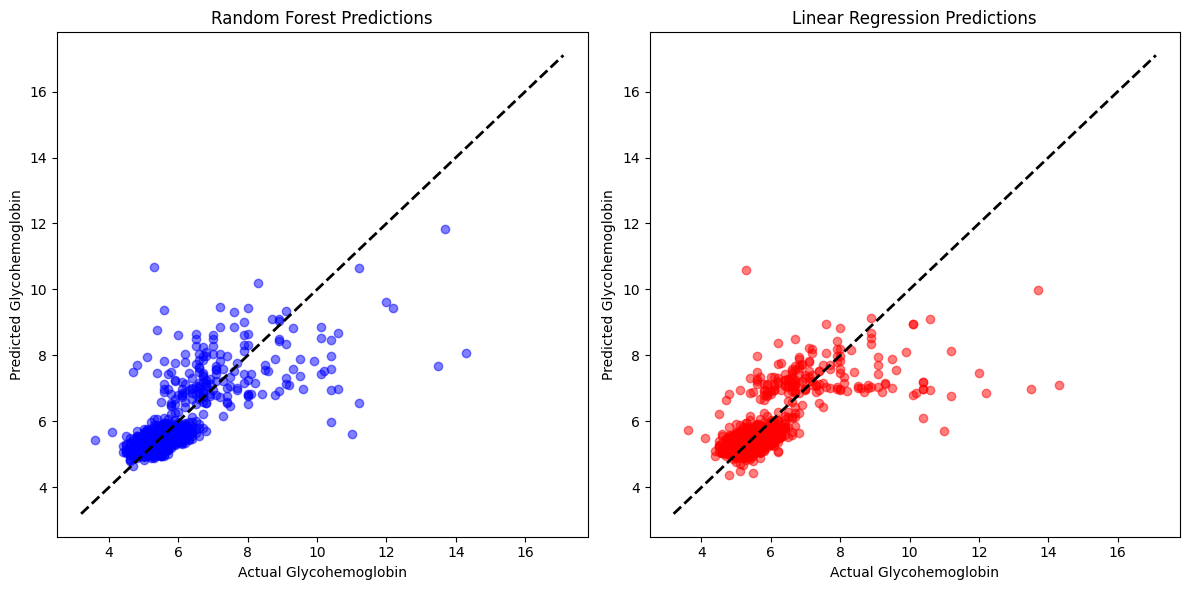

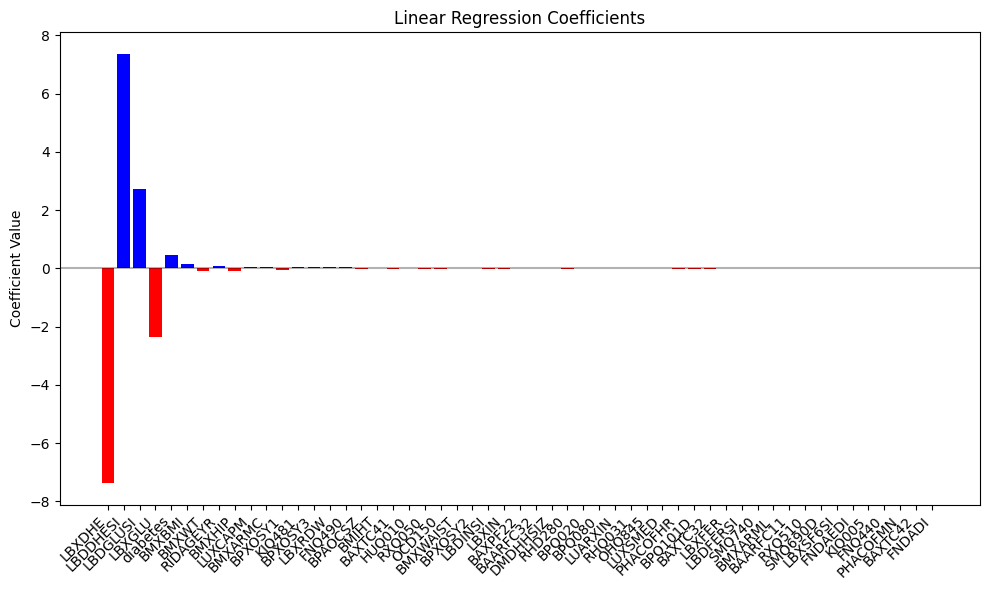


Linear Regression Coefficients:
RXQ050: -0.0252
OHQ845: 0.0103
RXQ510: -0.0041
LUARXIN: 0.0117
LUXSMED: 0.0094
LUXCAPM: 0.0622
KIQ005: -0.0018
KIQ481: 0.0388
LBXSF6SI: -0.0020
RHQ031: 0.0111
RHD280: -0.0188
LBXRDW: 0.0355
FNQ440: -0.0015
FNQ490: 0.0348
FNDADI: -0.0009
FNDAEDI: 0.0018
LBXDHE: -7.3693
LBDDHESI: 7.3636
LBXGLU: -2.3516
LBDGLUSI: 2.7284
SMQ740: 0.0064
SMQ690D: -0.0035
BPAOCSZ: -0.0291
BPXOSY1: -0.0423
BPXOSY2: 0.0210
BPXOSY3: 0.0376
HUQ010: 0.0277
RIDAGEYR: 0.0756
DMDHHSIZ: 0.0189
BMXWT: -0.0885
BMIHT: 0.0284
BMXBMI: 0.1495
BMXARML: 0.0051
BMXARMC: 0.0433
BMXWAIST: 0.0226
BMXHIP: -0.0742
BAARFC11: 0.0048
BAXPF22: 0.0196
BAXTC32: -0.0079
BAARFC32: 0.0192
BAXTC41: -0.0283
BAXTC42: -0.0012
LBXFER: 0.0069
LBDFERSI: 0.0069
PHACOFHR: -0.0091
PHACOFMN: -0.0012
BPQ020: 0.0140
BPQ080: 0.0122
BPQ101D: -0.0080
OCD150: -0.0233
LBXIN: -0.0203
LBDINSI: -0.0203
diabetes: 0.4597

Updated Model Comparison:
Random Forest R^2: 0.5522
Linear Regression R^2: 0.5138
Difference: 0.0384


In [35]:
# Add Linear Regression for Glycohemoglobin prediction
if 'LBXGH' in df_ml.columns:
    # Create a linear regression pipeline
    linear_reg_pipeline = Pipeline(steps=[
        ('preprocessor', reg_preprocessor),
        ('regressor', LinearRegression())
    ])
    
    # Train the linear regression model
    linear_reg_pipeline.fit(X_reg_train, y_reg_train)
    
    # Evaluate linear regression performance
    linear_y_pred = linear_reg_pipeline.predict(X_reg_test)
    linear_mse = mean_squared_error(y_reg_test, linear_y_pred)
    linear_r2 = r2_score(y_reg_test, linear_y_pred)
    
    print("\nLinear Regression for Glycohemoglobin (LBXGH) Prediction:")
    print(f"Mean Squared Error: {linear_mse:.4f}")
    print(f"R^2 Score: {linear_r2:.4f}")
    
    # Compare with Random Forest Regressor
    print("\nModel Comparison:")
    print(f"Random Forest R^2: {r2:.4f}")
    print(f"Linear Regression R^2: {linear_r2:.4f}")
    
    # Visualize predictions from both models
    plt.figure(figsize=(12, 6))
    
    # Random Forest predictions
    plt.subplot(1, 2, 1)
    plt.scatter(y_reg_test, y_reg_pred, alpha=0.5, color='blue')
    plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'k--', lw=2)
    plt.xlabel('Actual Glycohemoglobin')
    plt.ylabel('Predicted Glycohemoglobin')
    plt.title('Random Forest Predictions')
    
    # Linear Regression predictions
    plt.subplot(1, 2, 2)
    plt.scatter(y_reg_test, linear_y_pred, alpha=0.5, color='red')
    plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'k--', lw=2)
    plt.xlabel('Actual Glycohemoglobin')
    plt.ylabel('Predicted Glycohemoglobin')
    plt.title('Linear Regression Predictions')
    
    plt.tight_layout()
    plt.show()
    
    # Plot feature coefficients for linear model
    if hasattr(linear_reg_pipeline.named_steps['regressor'], 'coef_'):
        # Get coefficients
        coefficients = linear_reg_pipeline.named_steps['regressor'].coef_
        
        # Create a DataFrame for visualization
        coef_df = pd.DataFrame({
            'Feature': reg_features,
            'Coefficient': coefficients
        })
        
        # Sort by absolute coefficient value
        coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
        coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
        
        # Plot
        plt.figure(figsize=(10, 6))
        colors = ['red' if c < 0 else 'blue' for c in coef_df['Coefficient']]
        plt.bar(coef_df['Feature'], coef_df['Coefficient'], color=colors)
        plt.xticks(rotation=45, ha='right')
        plt.title('Linear Regression Coefficients')
        plt.ylabel('Coefficient Value')
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Print feature coefficients with descriptions when available
        print("\nLinear Regression Coefficients:")
        for feature, coef in zip(reg_features, coefficients):
            print(f"{feature}: {coef:.4f}")
    
    # Update the model summary cell to include linear regression
    print("\nUpdated Model Comparison:")
    print(f"Random Forest R^2: {r2:.4f}")
    print(f"Linear Regression R^2: {linear_r2:.4f}")
    print(f"Difference: {abs(r2 - linear_r2):.4f}")

In [36]:
# Model Summary
print(f"1. Classification Models (Diabetes Prediction):")
print(f"   - Random Forest:       {results['Random Forest'].mean():.4f} ± {results['Random Forest'].std():.4f}")
print(f"   - Logistic Regression: {results['Logistic Regression'].mean():.4f} ± {results['Logistic Regression'].std():.4f}")
print(f"   - Best model accuracy:  {max([results[model].mean() for model in results]):.4f}")

print(f"\n2. Top features for diabetes prediction (by importance):")
for i in indices[:3]:
    feature = feature_names[i]
    print(f"   - {feature}: {feature_importance[i]:.4f}")

print(f"\n3. Classification Performance:")
print(f"   - Precision for diabetes detection: {classification_report(y_test, y_pred).split()[11]}")
print(f"   - Recall for diabetes detection:    {classification_report(y_test, y_pred).split()[12]}")
print(f"   - F1-score for diabetes detection:  {classification_report(y_test, y_pred).split()[13]}")

if 'LBXGH' in df_ml.columns:
    print(f"\n4. Glycohemoglobin Regression Models:")
    print(f"   - Random Forest R^2:       {r2:.4f}")
    print(f"   - Linear Regression R^2:   {linear_r2:.4f}")
    print(f"   - Mean Squared Error:     {mse:.4f}")

1. Classification Models (Diabetes Prediction):
   - Random Forest:       0.9397 ± 0.0058
   - Logistic Regression: 0.9316 ± 0.0033
   - Best model accuracy:  0.9397

2. Top features for diabetes prediction (by importance):
   - LBXGH: 0.2730
   - LBDGLUSI: 0.0712
   - LBXGLU: 0.0631

3. Classification Performance:
   - Precision for diabetes detection: 0.70
   - Recall for diabetes detection:    0.78
   - F1-score for diabetes detection:  165

4. Glycohemoglobin Regression Models:
   - Random Forest R^2:       0.5522
   - Linear Regression R^2:   0.5138
   - Mean Squared Error:     0.4634


---
# Experimenting With Removing Highly Correlated Datasets

**Goal:** Get stuff other than obvious predictors

In [37]:
# import diabetes dataset
file_path = "diabetes_data/Diabetes_DIQ_L.xpt"
df, meta = pyreadstat.read_xport(file_path, encoding='cp1252')
df = df[['SEQN','DIQ010']]


# goes through all other files and merges them into the dataframe
dir = 'all_data'
ind = 0
skip = {'BAX_L.xpt', 'BMX_L.xpt', 'BPQ_L.xpt', 'BPXO_L.xpt', 'FNQ_L.xpt', 'LUX_L.xpt', 'GLU_L.xpt', 'GHB_L.xpt'}
for file in os.scandir(dir):
    if file.is_file():
        if file.name in skip:
            continue
        ind += 1
        newdf, meta = pyreadstat.read_xport(file, encoding='cp1252')
        df = df.merge(newdf, on="SEQN", how="left", copy=False, suffixes=[f'_x{ind}', f'_y{ind}'])

# create csv from combined dataframe
print(df.head())
df.to_csv('skipped_data.csv', index=False)

       SEQN  DIQ010  URXPREG  RXQ033  RXQ050   WTPH2YR_x10  LBXHSCRP  \
0  130378.0     2.0      NaN     1.0     1.0  56042.129410      1.78   
1  130379.0     2.0      NaN     1.0     1.0  37435.705647      2.03   
2  130380.0     1.0      2.0     1.0     1.0  85328.844519      5.62   
3  130381.0     2.0      NaN     1.0     2.0      0.000000       NaN   
4  130382.0     2.0      NaN     2.0     NaN  59638.932323       NaN   

   LBDHRPLC  HEQ010  OHQ845  ...  ALQ151  ALQ170  SMQ020  SMQ040  SMD641  \
0       0.0     2.0     1.0  ...     NaN     NaN     1.0     3.0     NaN   
1       0.0     2.0     2.0  ...     2.0     NaN     1.0     3.0     NaN   
2       0.0     2.0     4.0  ...     2.0     NaN     2.0     NaN     NaN   
3       NaN     NaN     1.0  ...     NaN     NaN     NaN     NaN     NaN   
4       NaN     NaN     1.0  ...     NaN     NaN     NaN     NaN     NaN   

   SMD650  SMD100MN  SMQ621  SMD630  SMAQUEX2  
0     NaN       NaN     NaN     NaN       1.0  
1     NaN     

In [38]:
# Use the dataset with your identified correlated features
df = pd.read_csv('skipped_data.csv')

# Define target variable (1 for diabetes, 2 for no diabetes)
# We'll convert it to a binary format (0 for no diabetes, 1 for diabetes)
df_ml = df.copy()

# Filter out missing values in the target
df_ml = df_ml[df_ml['DIQ010'].isin([1, 2])]  # Keep only Yes/No answers
df_ml['diabetes'] = np.where(df_ml['DIQ010'] == 1, 1, 0)  # 1=Yes, 2=No in original data

# Handling missing values and preprocessing
df_clean = df_ml.copy()
print(f"Initial data shape: {df_clean.shape}")

# Check missing values
missing_values = df_clean.isnull().sum()
print("\nMissing values by column:")
print(missing_values)

# Drop rows where too many features are missing (you may adjust this)
df_clean = df_clean.dropna(thresh=len(selected_features) // 2 + 2)  # Keep rows with at least half of features + target
print(f"After removing rows with too many missing values: {df_clean.shape}")

Initial data shape: (11452, 401)

Missing values by column:
SEQN            0
DIQ010          0
URXPREG     10342
RXQ033         21
RXQ050       5468
            ...  
SMD100MN    10316
SMQ621      10686
SMD630      11429
SMAQUEX2     2721
diabetes        0
Length: 401, dtype: int64
After removing rows with too many missing values: (11452, 401)


In [39]:
# Split the data
X = df_clean.drop(columns=['diabetes', 'DIQ010', 'SEQN'])
y = df_clean['diabetes']

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define preprocessing for numeric columns (scaling)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

# Create preprocessing and modeling pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Train the model
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['URXPREG', 'RXQ033', 'RXQ050', 'WTPH2YR_x10', 'LBXHSCRP', 'LBDHRPLC',
       'HEQ010', 'OHQ845', 'OHQ620', 'OHQ630',
       ...
       'ALQ151', 'ALQ170', 'SMQ020', 'SMQ040', 'SMD641', 'SMD650', 'SMD100MN',
       'SMQ621', 'SMD630', 'SMAQUEX2'],
      dtype='object', length=392))])),
                ('classifier', LogisticRegression(random_state=42))])

/var/folders/4c/xrxv09b531941dc_6xkrdcb40000gn/T/ipykernel_69830/1924501727.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_transformed, feature_names=feature_names)


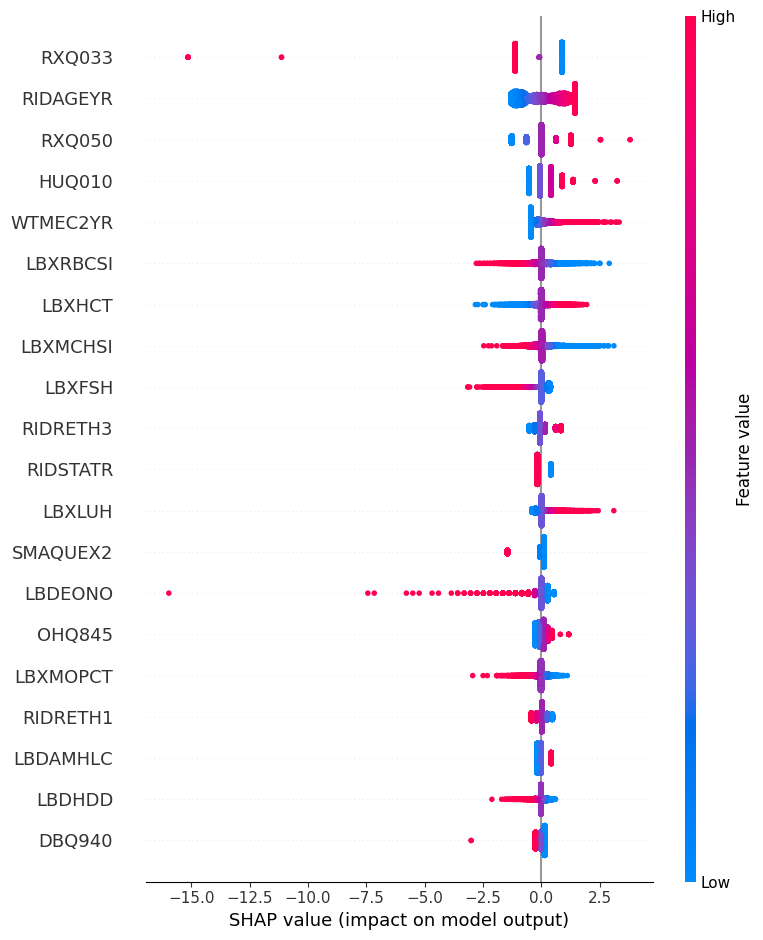

[('Taken prescription medicine, past month', 1.0069578915654656), ('Age in years at screening', 0.7809085062129795), ('Number of prescription medicines taken', 0.47517657307788863), ('General health condition', 0.4147891056188054), ('Full sample 2-year MEC exam weight', 0.33924686620569794), ('Red blood call count (million cells/uL)', 0.3065283869832792), ('Hematocrit (%)', 0.28004239597990005), ('Mean cell hemoglobin (pg)', 0.2593455809834576), ('Follicle Stimulating Hormone (mIU/mL)', 0.2519976233630762), ('Race/Hispanic origin w/ NH Asian', 0.2360514852232321), ('n', 0.2332603523519152), ('Luteinizing Horomone (mIU/mL)', 0.20447292090561583), ('Questionnaire Mode Flag', 0.19856616308193414), ('Eosinophils number (1000 cells/uL)', 0.19251594359966637), ('Rate the health of your teeth and gums', 0.18466854134713057)]


In [ ]:
# create and train pipeline for shap values
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]), numeric_features),
])
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
pipeline.fit(X_train, y_train)

#  transform the data using the preprocessor
X_transformed = pipeline.named_steps['preprocessor'].transform(X_train)

# get the classifier (which expects transformed input)
classifier = pipeline.named_steps['classifier']

# use SHAP's LinearExplainer for LogisticRegression
explainer = shap.LinearExplainer(classifier, X_transformed)

# compute SHAP values
shap_values = explainer(X_transformed)

# show shap plot
feature_names = numeric_features.tolist()  # or match the order after any encoding
shap.summary_plot(shap_values, features=X_transformed, feature_names=feature_names)

# prepare shap values for getting top 15
shap_df = pd.DataFrame(shap_values.values, columns=numeric_features)  # Use numeric_features for columns

mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

# Get top 15 features
shap_top_15 = mean_abs_shap.head(15)
shap_top_list = mean_abs_shap.head(15).tolist()

# If you want to map these feature names to some dictionary (like 'codeDict')
log_feature_names = shap_top_15.index.tolist()
log_top_15 = []

# Assuming 'codeDict' is defined to map feature names to some values
for i in range(len(log_feature_names)):
    feature = log_feature_names[i]
    log_top_15.append((codeDict[feature][1], shap_top_list[i]))  # Replace with your dictionary lookup logic

print(log_top_15)

In [41]:
# Try additional classifier models
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
}

# Compare models
results = {}
for name, classifier in classifiers.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    
    # Perform cross-validation
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    results[name] = cv_scores
    
    print(f"{name} - Cross-validation accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # Fit and predict
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"{name} - Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print()

/Users/asaucer/Desktop/School/Projects/CS426-Project/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['MCQ230D']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/Users/asaucer/Desktop/School/Projects/CS426-Project/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['MCQ230D']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Logistic Regression - Cross-validation accuracy: 0.9145 ± 0.0043
Logistic Regression - Test accuracy: 0.9075



/Users/asaucer/Desktop/School/Projects/CS426-Project/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['MCQ230D']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/Users/asaucer/Desktop/School/Projects/CS426-Project/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['MCQ230D']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Random Forest - Cross-validation accuracy: 0.9115 ± 0.0016
Random Forest - Test accuracy: 0.9149



In [ ]:
# Feature importance analysis with Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])
rf_model.fit(X_train, y_train)

# Extract feature importance
rf_classifier = rf_model.named_steps['classifier']
skip_feature_names = X.columns.tolist()
skip_feature_importance = rf_classifier.feature_importances_

# Sort features by importance
skip_indices = np.argsort(skip_feature_importance)[::-1]

# print top 15 features via feature importance
skip_top_15 = []
for i in range(0,15):
    feature = skip_feature_names[skip_indices[i]]
    importance = skip_feature_importance[skip_indices[i]]
    # Add check if feature exists in codeDict
    if feature in codeDict:
        description = codeDict[feature][1]
    else:
        # Handle missing features with a placeholder
        description = f"Unknown feature: {feature}"
    skip_top_15.append((description, importance))
print(skip_top_15)

[('Number of prescription medicines taken', np.float64(0.048253188109765234)), ('Dr told to take daily low-dose aspirin?', np.float64(0.020935314123020854)), ('Unknown feature: AUQ144', np.float64(0.020018938982083442)), ('Unknown feature: LBDBMNLC', np.float64(0.018963967351925227)), ('Unknown feature: PHASUPMN', np.float64(0.016930659538944074)), ('Unknown feature: PHASUPHR', np.float64(0.013838091148250197)), ('Unknown feature: WTPH2YR_x32', np.float64(0.011889131704703406)), ('Taken prescription medicine, past month', np.float64(0.011532367441341618)), ('Followed advice, took low-does aspirin', np.float64(0.0103121431930317)), ('Unknown feature: DMDHRAGZ', np.float64(0.009812574146440763)), ('Direct HDL-Cholesterol (mg/dL)', np.float64(0.009712019221433365)), ('Unknown feature: ECQ090', np.float64(0.00965050474314032)), ('Direct HDL-Cholesterol (mmol/L)', np.float64(0.009280652069806569)), ('Unknown feature: PHQ060', np.float64(0.009236017842126661)), ('Unknown feature: LBXSHBG', n

In [ ]:
# import csv
df = pd.read_csv('skipped_data.csv')

df_scorr = df.copy()

# Filter out missing values in the target
df_scorr = df_scorr[df_scorr['DIQ010'].isin([1, 2])]  # Keep only Yes/No answers
df_scorr['diabetes'] = np.where(df_scorr['DIQ010'] == 1, 1, 0)

df_clean = df_scorr.drop(columns=['DIQ010', 'SEQN'])

# get correlation values for diabetes
skipcorrmat = df_clean.corr(numeric_only=True)
round(skipcorrmat, 2)
correlations = skipcorrmat['diabetes'].dropna().tolist()[2:]
codes = skipcorrmat['diabetes'].dropna().keys().tolist()[2:]

# get info for features
skipfiltCorrs = []
for i in range(len(correlations)):
    skipfiltCorrs.append((codes[i], correlations[i]))

# sort and get top 15
skipsorted_corrs = sorted(skipfiltCorrs, key=lambda x: x[1], reverse=True)
skip_corr_top_15 = []
for i in range(1,16):
    feature = skipsorted_corrs[i][0]
    importance = skipsorted_corrs[i][1]
    skip_corr_top_15.append((codeDict[feature][1], importance))
print(skip_corr_top_15)

[('Number of prescription medicines taken', 0.3862591718577147), ('Age in years at screening', 0.3148759159375084), ('General health condition', 0.30817492474287117), ('Coffee/tea fast time (hours)', 0.2800416927886729), ('Rate the health of your teeth and gums', 0.21337814060464844), ('Had regular periods in past 12 months', 0.2122161388867004), ('Ferritin(ng/mL)', 0.20888810493365387), ('Ferritin(mewg/L)', 0.20888810493365387), ('Insulin (pmol/L)', 0.19171655811302205), ('Insulin (uU/mL)', 0.1917165581130218), ('Mefox oxidation product (nmol/L)', 0.17782047368898268), ('Type of work done last week', 0.17257817447264076), ('How often have urinary leakage', 0.1589936373741843), ('Red cell distribution width (%)', 0.1564153078539761), ('How many times wake up and urinate?', 0.1544771837779573)]
